TASK 1: Reporting total records, missing values and duplicate UPCs

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

In [2]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/202618002/books.csv')

In [3]:
df

,title,category,price,rating,availability,description,upc,num_reviews,product_url
0,It's Only the Himalayas,Travel,£45.17,2,In stock (19 available)\n \n \n \n \...,"“Wherever you go, whatever you do, just . . . ...",a22124811bfa8350,0,https://books.toscrape.com/catalogue/its-only-...
1,Libertarianism for Beginners,Politics,£51.33,2,In stock (19 available)\n \n \n \n \...,Libertarianism isn't about winning elections; ...,a18a4f574854aced,0,https://books.toscrape.com/catalogue/libertari...
2,Mesaerion: The Best Science Fiction Stories 18...,Science Fiction,£37.59,1,In stock (19 available)\n \n \n \n \...,"Andrew Barger, award-winning author and engine...",e30f54cea9b38190,0,https://books.toscrape.com/catalogue/mesaerion...
3,Olio,Poetry,£23.88,1,In stock (19 available)\n \n \n \n \...,"Part fact, part fiction, Tyehimba Jess's much ...",feb7cc7701ecf901,0,https://books.toscrape.com/catalogue/olio_984/...
4,Our Band Could Be Your Life: Scenes from the A...,Music,£57.25,3,In stock (19 available)\n \n \n \n \...,This is the never-before-told story of the mus...,deda3e61b9514b83,0,https://books.toscrape.com/catalogue/our-band-...
...,...,...,...,...,...,...,...,...,...
95,In Her Wake,Thriller,£12.84,1,In stock (19 available)\n \n \n \n \...,A perfect life … until she discovered it wasn’...,23356462d1320d61,0,https://books.toscrape.com/catalogue/in-her-wa...
96,Sharp Objects,Mystery,£47.82,4,In stock (20 available)\n \n \n \n \...,"WICKED above her hipbone, GIRL across her hear...",e00eb4fd7b871a48,0,https://books.toscrape.com/catalogue/sharp-obj...
97,Soumission,Fiction,£50.10,1,In stock (20 available)\n \n \n \n \...,"Dans une France assez proche de la nôtre, un h...",6957f44c3847a760,0,https://books.toscrape.com/catalogue/soumissio...
98,Tipping the Velvet,Historical Fiction,£53.74,1,In stock (20 available)\n \n \n \n \...,"""Erotic and absorbing...Written with starling ...",90fa61229261140a,0,https://books.toscrape.com/catalogue/tipping-t...


In [4]:
print(f"Raw records loaded: {len(df)}")

Raw records loaded: 100


In [5]:
print(df.isnull().sum())

title           0
category        0
price           0
rating          0
availability    0
description     0
upc             0
num_reviews     0
product_url     0
dtype: int64


No null values found, so we skip the step of treating missing values.

# TASK 2: Data Preprocessing

In [6]:
#clean up extra space

text_columns = ["title", "category", "availability", "description"]
for col in text_columns:
    df[col] = df[col].astype(str).str.strip()
    df[col] = df[col].str.replace(r"\s+", " ", regex=True)

In [7]:
duplicate_upc_count = df['upc'].duplicated().sum()
print(duplicate_upc_count)

0


Removing symbols from price and converting type to float

In [8]:
df['price'] = df['price'].str.replace(r'[^\d.]', '', regex=True).astype(float)

Converting ratings to numeric type

In [9]:
df["rating"] = pd.to_numeric(df["rating"], errors="coerce")

In [10]:
df["stock_count"] = (
    df["availability"].str.extract(r"\((\d+)\s*available\)").astype(float)
)
df["stock_count"] = df["stock_count"].fillna(0).astype(int)

Creating some features that might be useful for analysis

In [11]:
df["description_word_count"] = df["description"].str.split().str.len()

In [12]:
df['price_band'] = pd.qcut(df['price'], q=3, labels=['Low', 'Medium', 'High'])

In [13]:
fiction_categories = ['Sequential Art', 'Fiction', 'Fantasy', 'Young Adult', 'Mystery',
                     'Thriller', 'Romance', 'Science Fiction', 'Horror', 'Contemporary',
                     'Historical Fiction', 'Childrens']

df['is_fiction'] = df['category'].isin(fiction_categories)

In [15]:
df[["title", "price", "rating", "description_word_count", "is_fiction", "price_band"]].head()

,title,price,rating,description_word_count,is_fiction,price_band
0,It's Only the Himalayas,45.17,2,230,False,High
1,Libertarianism for Beginners,51.33,2,195,False,High
2,Mesaerion: The Best Science Fiction Stories 18...,37.59,1,283,True,Medium
3,Olio,23.88,1,249,False,Medium
4,Our Band Could Be Your Life: Scenes from the A...,57.25,3,163,False,High


In [16]:
df

,title,category,price,rating,availability,description,upc,num_reviews,product_url,stock_count,description_word_count,price_band,is_fiction
0,It's Only the Himalayas,Travel,45.17,2,In stock (19 available) In stock In stock In s...,"“Wherever you go, whatever you do, just . . . ...",a22124811bfa8350,0,https://books.toscrape.com/catalogue/its-only-...,19,230,High,False
1,Libertarianism for Beginners,Politics,51.33,2,In stock (19 available) In stock In stock In s...,Libertarianism isn't about winning elections; ...,a18a4f574854aced,0,https://books.toscrape.com/catalogue/libertari...,19,195,High,False
2,Mesaerion: The Best Science Fiction Stories 18...,Science Fiction,37.59,1,In stock (19 available) In stock In stock In s...,"Andrew Barger, award-winning author and engine...",e30f54cea9b38190,0,https://books.toscrape.com/catalogue/mesaerion...,19,283,Medium,True
3,Olio,Poetry,23.88,1,In stock (19 available) In stock In stock In s...,"Part fact, part fiction, Tyehimba Jess's much ...",feb7cc7701ecf901,0,https://books.toscrape.com/catalogue/olio_984/...,19,249,Medium,False
4,Our Band Could Be Your Life: Scenes from the A...,Music,57.25,3,In stock (19 available) In stock In stock In s...,This is the never-before-told story of the mus...,deda3e61b9514b83,0,https://books.toscrape.com/catalogue/our-band-...,19,163,High,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,In Her Wake,Thriller,12.84,1,In stock (19 available) In stock In stock In s...,A perfect life … until she discovered it wasn’...,23356462d1320d61,0,https://books.toscrape.com/catalogue/in-her-wa...,19,159,Low,True
96,Sharp Objects,Mystery,47.82,4,In stock (20 available) In stock In stock In s...,"WICKED above her hipbone, GIRL across her hear...",e00eb4fd7b871a48,0,https://books.toscrape.com/catalogue/sharp-obj...,20,274,High,True
97,Soumission,Fiction,50.10,1,In stock (20 available) In stock In stock,"Dans une France assez proche de la nôtre, un h...",6957f44c3847a760,0,https://books.toscrape.com/catalogue/soumissio...,20,163,High,True
98,Tipping the Velvet,Historical Fiction,53.74,1,In stock (20 available) In stock,"""Erotic and absorbing...Written with starling ...",90fa61229261140a,0,https://books.toscrape.com/catalogue/tipping-t...,20,165,High,True


In [17]:
df.to_csv("books_cleaned.csv", index=False)
print("Saved cleaned data")

Saved cleaned data


# TASK 3: VISUALISATION AND ANALYSIS

/tmp/ipykernel_35755/637658285.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='rating', palette='viridis', ax=axes[0, 1])
/tmp/ipykernel_35755/637658285.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_price_cat.values, y=avg_price_cat.index, palette='magma', ax=axes[1, 0])
/tmp/ipykernel_35755/637658285.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_rating_cat.values, y=avg_rating_cat.index, palette='mako')


Plot saved as books_analysis.png


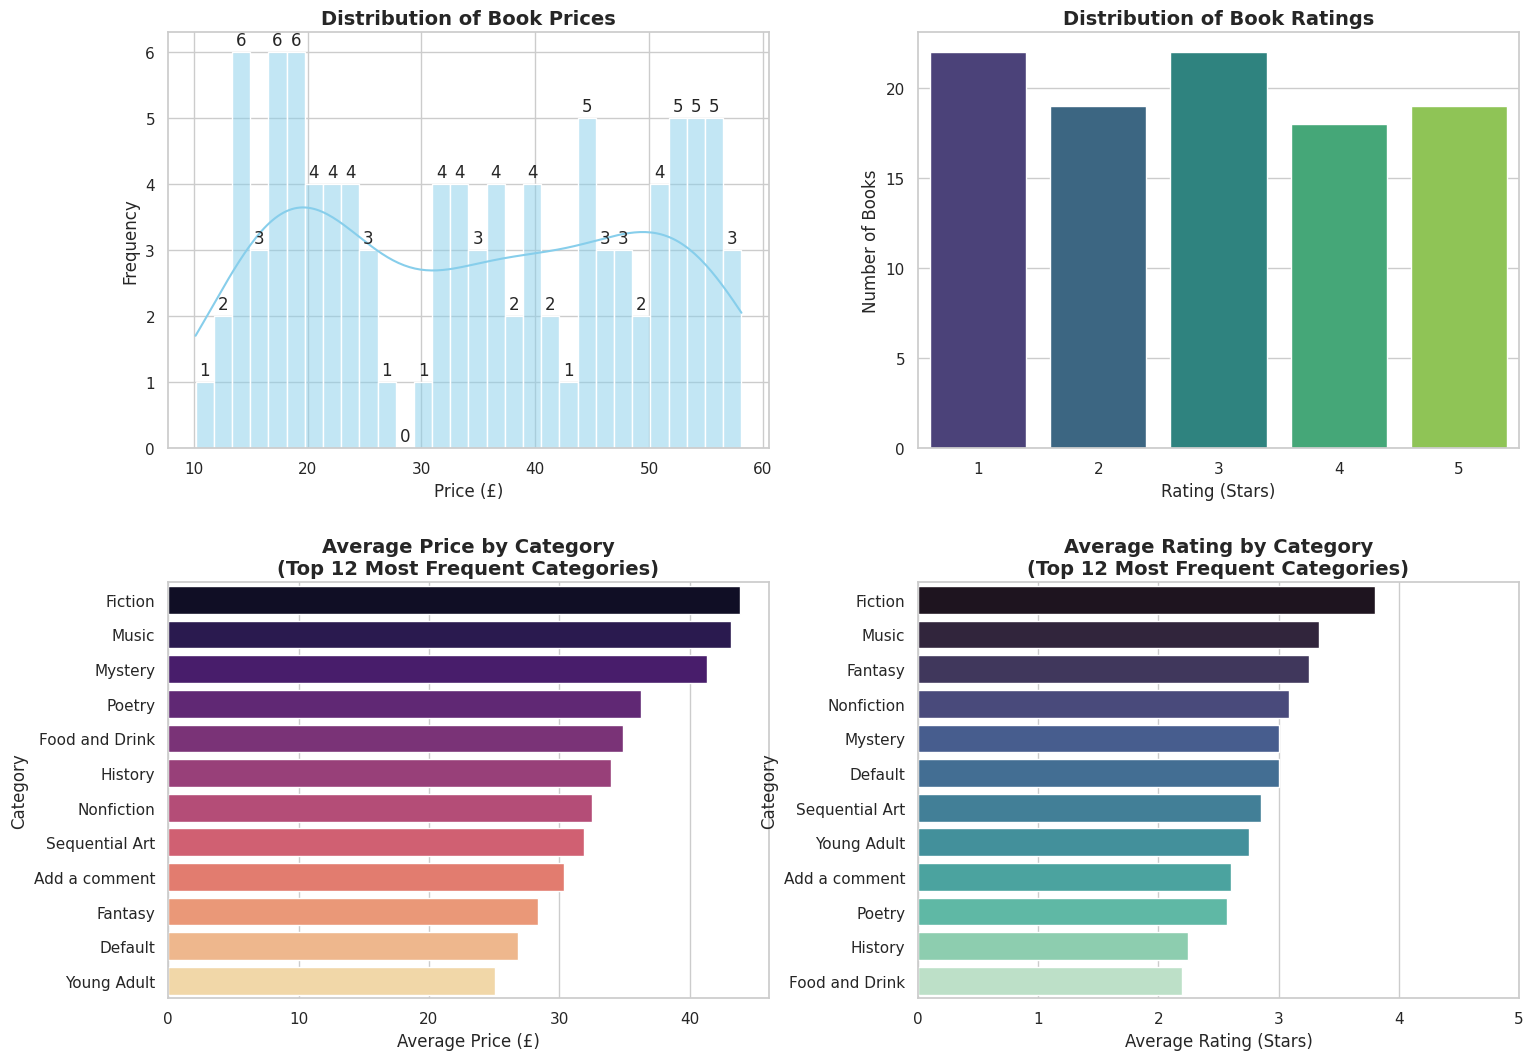

In [29]:
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.tight_layout(pad=6.0)

# 1. Price Distribution
sns.histplot(df['price'], bins=30, kde=True, ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('Distribution of Book Prices', fontsize=14, weight='bold')
axes[0, 0].set_xlabel('Price (£)', fontsize=12)
axes[0, 0].set_ylabel('Frequency', fontsize=12)
axes[0, 0].bar_label(axes[0, 0].containers[0], fmt='%.0f', label_type='edge', padding=2)

# 2. Rating Distribution
sns.countplot(data=df, x='rating', palette='viridis', ax=axes[0, 1])
axes[0, 1].set_title('Distribution of Book Ratings', fontsize=14, weight='bold')
axes[0, 1].set_xlabel('Rating (Stars)', fontsize=12)
axes[0, 1].set_ylabel('Number of Books', fontsize=12)

# 3. Average Price by Category (Top 12 most frequent categories)
top_categories = df['category'].value_counts().nlargest(12).index
df_top_cat = df[df['category'].isin(top_categories)]
avg_price_cat = df_top_cat.groupby('category')['price'].mean().sort_values(ascending=False)

sns.barplot(x=avg_price_cat.values, y=avg_price_cat.index, palette='magma', ax=axes[1, 0])
axes[1, 0].set_title('Average Price by Category\n(Top 12 Most Frequent Categories)', fontsize=14, weight='bold')
axes[1, 0].set_xlabel('Average Price (£)', fontsize=12)
axes[1, 0].set_ylabel('Category', fontsize=12)

# 4. Relationship Plot: Avg Rating vs Category
avg_rating_cat = df_top_cat.groupby('category')['rating'].mean().sort_values(ascending=False)
sns.barplot(x=avg_rating_cat.values, y=avg_rating_cat.index, palette='mako')

plt.title('Average Rating by Category\n(Top 12 Most Frequent Categories)', fontsize=14, weight='bold')
plt.xlabel('Average Rating (Stars)', fontsize=12)
plt.ylabel('Category', fontsize=12)
plt.xlim(0, 5)

plt.savefig('books_analysis.png', bbox_inches='tight')
print("Plot saved as books_analysis.png")

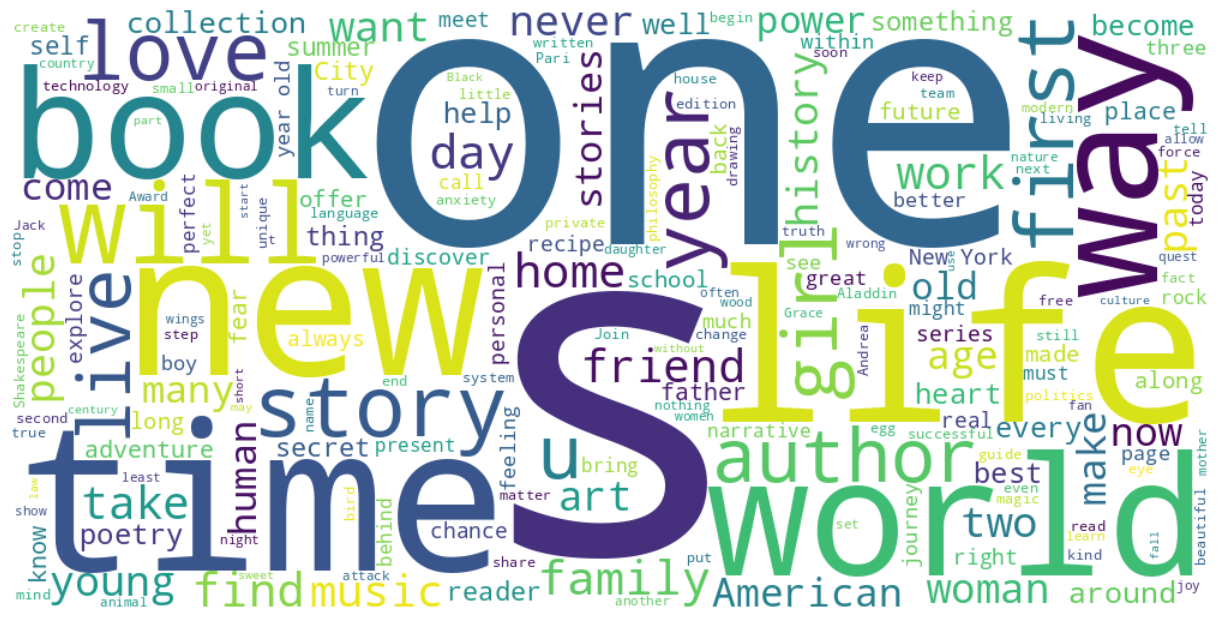

In [19]:
from wordcloud import WordCloud, STOPWORDS

# Filter out missing values and combine all descriptions into a single string
text = " ".join(desc for desc in df['description'].dropna() if isinstance(desc, str))

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white',
    stopwords=STOPWORDS,
    colormap='viridis',
    max_words=200
).generate(text)


plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.tight_layout(pad=0)
plt.savefig('description_wordcloud.png')

In [20]:
summary_stats = df[['price', 'rating', 'stock_count', 'num_reviews', 'description_word_count']].describe()
print("--- Summary Statistics ---")
print(summary_stats)

--- Summary Statistics ---
            price      rating  stock_count  num_reviews  \
count  100.000000  100.000000   100.000000        100.0   
mean    34.560700    2.930000    17.180000          0.0   
std     14.638531    1.423149     1.479694          0.0   
min     10.160000    1.000000    16.000000          0.0   
25%     19.897500    2.000000    16.000000          0.0   
50%     34.775000    3.000000    16.000000          0.0   
75%     47.967500    4.000000    19.000000          0.0   
max     58.110000    5.000000    22.000000          0.0   

       description_word_count  
count              100.000000  
mean               224.710000  
std                107.798474  
min                 36.000000  
25%                163.750000  
50%                211.500000  
75%                276.500000  
max                722.000000  


In [21]:
highly_rated = df[df['rating'] == 5]
highly_rated_cats = highly_rated['category'].value_counts()

In [22]:
highly_rated_cats

,count
category,
Fiction,3
Nonfiction,2
Romance,2
Spirituality,2
Sequential Art,2
Philosophy,1
History,1
Young Adult,1
Music,1


In [30]:
# Correlation between price and rating
correlation = df['price'].corr(df['rating'])
print(f"Correlation between Price and Rating: {correlation:.4f}\n")



Correlation between Price and Rating: -0.1217



In [34]:
# Correlation between price and stock
correlation1 = df['price'].corr(df['stock_count'])
print(f"Correlation between Price and stock: {correlation1:.4f}\n")

Correlation between Price and stock: 0.1083



In [35]:
# Correlation between stock and rating
correlation2 = df['stock_count'].corr(df['rating'])
print(f"Correlation between stock and Rating: {correlation2:.4f}\n")

Correlation between stock and Rating: 0.0636



In [32]:
# Most represented and most expensive categories
most_represented = df['category'].value_counts().head(5)
print("--- Top 5 Most Represented Categories ---")
print(most_represented, "\n")

most_expensive = df.groupby('category')['price'].mean().sort_values(ascending=False).head(5)
print("--- Top 5 Most Expensive Categories (Average Price) ---")
print(most_expensive, "\n")


--- Top 5 Most Represented Categories ---
category
Sequential Art    14
Nonfiction        12
Default            9
Poetry             7
Fiction            5
Name: count, dtype: int64 

--- Top 5 Most Expensive Categories (Average Price) ---
category
Historical Fiction    53.74
Politics              51.33
Childrens             49.22
Health                49.05
Self Help             46.35
Name: price, dtype: float64 



In [33]:
# Best value books (High Rating, Low Price)
# Creating a 'value_score' (Rating per £ spent)
df['value_score'] = df['rating'] / df['price']
best_value = df.sort_values(by='value_score', ascending=False).head(5)

print("--- Top 5 Best Value Books ---")
print(best_value[['title', 'category', 'rating', 'price', 'value_score']])

--- Top 5 Best Value Books ---
                                                title        category  rating  \
82   Princess Between Worlds (Wide-Awake Princess #5)         Fantasy       5   
83  Princess Jellyfish 2-in-1 Omnibus, Vol. 01 (Pr...  Sequential Art       5   
21                                     Sophie's World      Philosophy       5   
79                                           Patience  Sequential Art       3   
37                                             Thirst         Fiction       5   

    price  value_score  
82  13.34     0.374813  
83  13.61     0.367377  
21  15.94     0.313676  
79  10.16     0.295276  
37  17.27     0.289519  


# OBSERVATIONS AND INSIGHTS

The data was scraped from 5 pages and there are 100 books of multiple genres. The collected data contained info on multiple attributes like category,	price,	rating,	availability of stock,	description, etc.


From the summary statistics and correlation, it is understood that there is
1. Almost no correlation between price and rating. This means that a higher price doesn't necessarily mean a better book. A book priced at 51.33 is rated 2 while a book priced at 47.82 is rated 4.

2. The price ranges from a minimum of 10.16 to 58.11 euros.

3. There is a specific price point around 30 euros, where there is no book priced at that price showing a sharp dip in the graph(figure - distribution of book prices)

4. The inventory or stock level maintained is stable throughout the data, as all the books have 16 to 22 units in stock.

5. The correlation between stock and price is very weak suggesting that price of a book doesnt affect the stock levels. Similarly, ratings of a book doesn't affect the stock count.

6. Princess Between Worlds(Wide-Awake Princess #5) in the Fantasy category is priced at 13.34 euros and has a rating of 5 stars which surely makes it the best value for money book in the dataset.



# LIMITATIONS OF SCRAPED DATA and ANALYSIS

1. Since only 5 pages of the website(or 100 books) were scraped, there was very limited amount of data available to analyse upon or judge how the rest of the books in the website would be.

2. Every book having strictly 16 to 22 units of stock is unrealistic. Real time data would have varying quantities of stock ranging from 0 to thousands.

3. Since there were no reviews on the books, it is not possible to understand how the book is just based on the description. The num_reviews column was also completely 0.

4. The small size of data omits the existence of other genres which really doesn't help to get good insights.

5. A fixed price of the book is again unrealistic. In real time, the prices and stock counts of products are dynamic.

6. This was a dummy site that allowed us to scrape for free and was made for such purpose. Other websites might not allow us to scrape so easily and might have restrictions on scraping policies.